# Build matrix of interactions

In [52]:
import os
import pandas as pd
from plip.structure.preparation import PDBComplex

# Protein names (longest first to avoid partial matches)
proteins = [
    #"PDE4B_monomer_md",
    #"PDE4B_dimer",
    "PDE4D_catalytic",
]

interaction_types = [
    "hydrophobic_contacts",
    "hbonds_ldon",
    "hbonds_pdon",
    "water_bridges",
    "saltbridge_lneg",
    "saltbridge_pneg",
    "pistacking",
    "pication_laro",
    "pication_paro",
    "halogen_bonds",
    "metal_complexes",
]

rows = []

pdb_folder = "../pdbs"

for pdb_file in sorted(os.listdir(pdb_folder)):
    print(pdb_file)
    if not pdb_file.endswith(".pdb"):
        continue

    basename = os.path.splitext(pdb_file)[0]

    # Identify protein and ligand from filename
    protein = None
    ligand = None
    for p in proteins:
        if basename.startswith(p + "_"):
            protein = p
            ligand = basename[len(p) + 1:]
            break

    if protein is None:
        print(f"Skipping {pdb_file}: protein not recognized.")
        continue

    pdb_path = os.path.join(pdb_folder, pdb_file)

    mol = PDBComplex()
    mol.load_pdb(pdb_path)
    mol.analyze()

    for bsid, inter in mol.interaction_sets.items():

        # # Ignore cofactors/ions (keep only the docked ligand)
        # if inter.ligand.hetid != "UNL":
        #     continue

        for interaction_type in interaction_types:

            if not hasattr(inter, interaction_type):
                continue

            interactions = getattr(inter, interaction_type)

            for i in interactions:

                rows.append({
                    "protein": protein,
                    "ligand": ligand,
                    "binding_site": bsid,
                    "interaction_type": interaction_type,
                    "residue_number": getattr(i, "resnr", None),
                    "residue_name": getattr(i, "restype", None),
                    "residue_chain": getattr(i, "reschain", None),
                })


ModuleNotFoundError: No module named 'plip'

In [ ]:
# convert the list of dict to df 
df = pd.DataFrame(rows)

# create res id column with name, position and chain
df["residue_id"] = (
    df["residue_name"].astype(str) +
    df["residue_number"].astype("Int64").astype(str) +
    ":" +
    df["residue_chain"].astype(str)
)

df.to_csv("protein_interactions.csv", index=False)


In [1]:
import pandas as pd

df = pd.read_csv('plip_interactions.csv')
#df = pd.read_csv('/home/gbiuser/Documents/vitoria/usp-masters/8-docking/interactions/protein_interactions.csv')    
print(df.shape)
print(df.columns)

(3650, 47)
Index(['protein', 'ligand', 'binding_site', 'interaction_type', 'resnr',
       'restype', 'reschain', 'resnr_lig', 'restype_lig', 'reschain_lig',
       'dist', 'ligcoo', 'protcoo', 'sidechain', 'dist_h-a', 'dist_d-a',
       'don_angle', 'protisdon', 'donoridx', 'donortype', 'acceptoridx',
       'acceptortype', 'dist_a-w', 'dist_d-w', 'water_angle', 'water_idx',
       'acc_angle', 'protispos', 'lig_group', 'lig_idx_list', 'cent_dist',
       'angle', 'offset', 'type', 'protcharged', 'metalcoo', 'targetcoo',
       'metal_idx', 'metal_type', 'target_idx', 'target_type', 'coordination',
       'location', 'rms', 'geometry', 'complexnum', 'residue_id'],
      dtype='object')


In [2]:
df["protein"].value_counts()

protein
PDE4D_dimer        860
PDE4D_catalytic    851
PDE4B_monomer      717
PDE4B_catalytic    692
PDE4B_dimer        656
PDE4D_monomer      585
Name: count, dtype: int64

## Conserved residues across all complexes

In [2]:
# create df disconsindering ions
df_lig = df[df["binding_site"].str.startswith("UNL:")].copy()


In [5]:
# aggregate number of interactions based on number of proteins and ligands 
conserved = (
    df_lig.groupby("residue_id")
            .agg(
                n_proteins=("protein", "nunique"),
                n_ligands=("ligand", "nunique"),
                n_complexes=("protein", lambda x: len(set(zip(x, df.loc[x.index, "ligand"])))),
            )         
            .reset_index()
)

In [6]:
conserved.sort_values("n_complexes", ascending=False).head(20)

,residue_id,n_proteins,n_ligands,n_complexes
76,PHE453:A,3,20,53
80,PHE618:A,3,20,53
109,TYR405:A,3,20,44
52,ILE582:A,3,20,42
49,ILE417:A,3,20,42
74,PHE421:A,3,19,33
79,PHE586:A,3,19,33
75,PHE452:A,2,18,32
7,ASN567:A,3,15,30
48,ILE416:A,2,18,29


In [8]:
conserved.sort_values("n_proteins", ascending=False).head(20)

,residue_id,n_proteins,n_ligands,n_complexes
50,ILE582:A,3,20,30
23,GLN615:A,3,17,29
20,GLN450:A,3,16,23
47,ILE417:A,3,20,29
89,SER614:A,3,5,6
9,ASN567:A,2,15,19
18,GLN423:A,2,2,2
15,ASP564:A,2,16,20
46,ILE416:A,2,18,29
39,HIS406:A,2,12,18


### Conserved only in PDE4B

In [4]:
PDE4B_subset = [
    "PDE4B_dimer",
    "PDE4B_monomer",
    "PDE4B_catalytic"
]

df_subset = df_lig[
    df_lig["protein"].isin(PDE4B_subset)
].copy()

conserved_PDE4B = (
    df_subset.groupby("residue_id")
             .agg(
                 n_proteins=("protein", "nunique"),
                 n_ligands=("ligand", "nunique"),
                 n_complexes=("protein", lambda x: len(set(zip(x, df_subset.loc[x.index, "ligand"]))))
             )
             .reset_index()
             .sort_values(
                 ["n_proteins", "n_ligands"],
                 ascending=False
             )
)



In [5]:
conserved_PDE4B.head(30)

,residue_id,n_proteins,n_ligands,n_complexes
12,ILE582:A,3,20,42
18,PHE618:A,3,20,53
26,TYR405:A,3,20,46
17,PHE586:A,3,19,33
8,HIS406:A,3,18,34
5,GLN615:A,3,17,28
1,ASN567:A,3,16,30
3,ASP564:A,3,16,23
14,LEU565:A,3,12,19
15,MET519:A,3,10,13


check pde4b other chain

In [14]:
df_lig[(df_lig["protein"] == "PDE4B_dimer") & (df_lig["residue_chain"] == "B")]

,protein,ligand,binding_site,interaction_type,residue_number,residue_name,residue_chain,residue_id


In [15]:
df_lig[(df_lig["protein"] == "PDE4D_dimer") & (df_lig["residue_chain"] == "B")]

,protein,ligand,binding_site,interaction_type,residue_number,residue_name,residue_chain,residue_id


## Interaction fingerprint (IFP) analysis

In [15]:
fp_ligand = (
    df_lig.assign(value=1)
          .pivot_table(
              index="ligand",
              columns="residue_id",
              values="value",
              aggfunc="max",
              fill_value=0
          )
)


In [16]:
known = ["rolR", "rf", "rolS"]

known_fp = fp_ligand.loc[known]

shared = known_fp.sum(axis=0) == len(known)


### Clustering

In [17]:
fp = (
    df_lig.assign(value=1)
           .pivot_table(
               index=["protein", "ligand"],
               columns="residue_id",
               values="value",
               aggfunc="max",
               fill_value=0
           )
)

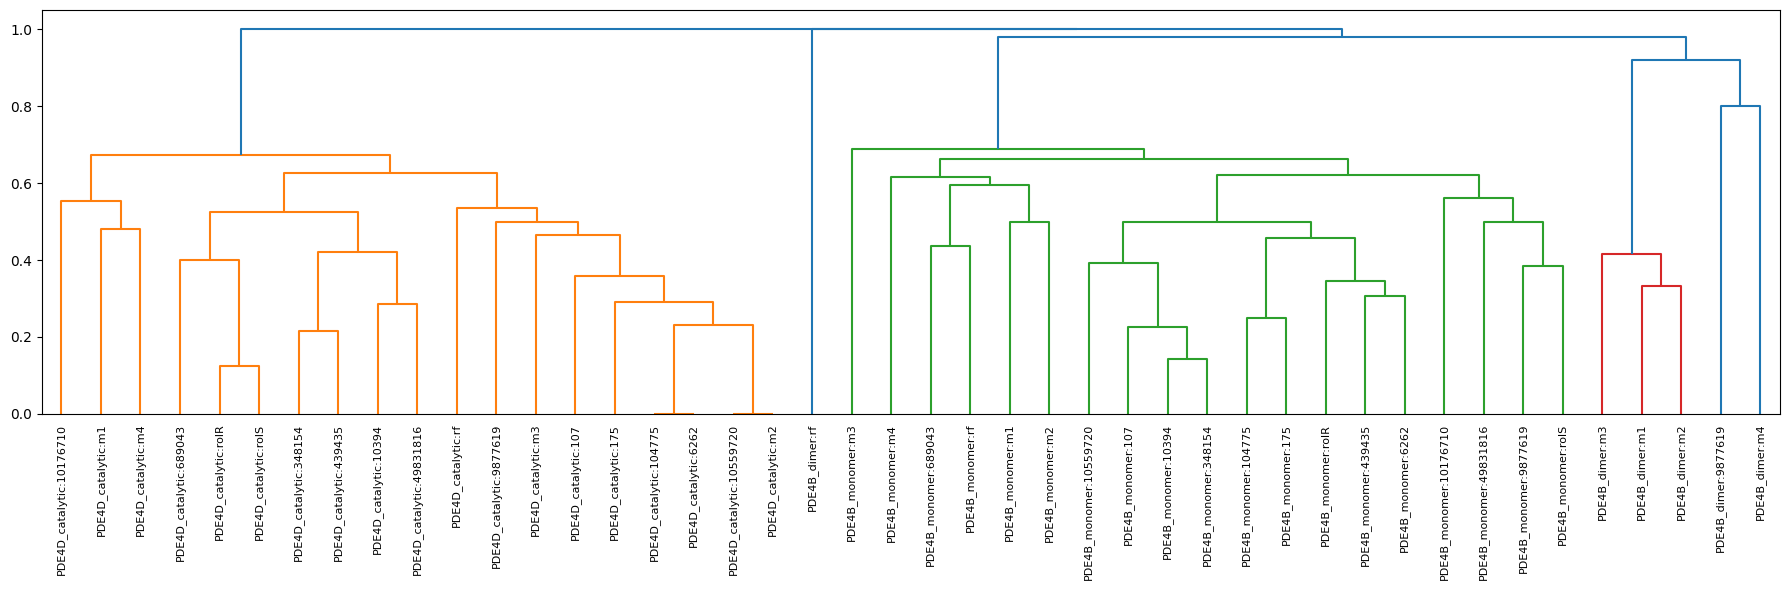

In [18]:
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

distance = pdist(fp.values, metric="jaccard")

Z = linkage(distance, method="average")

plt.figure(figsize=(18,6))

dendrogram(
    Z,
    labels=[f"{p}:{l}" for p, l in fp.index],
    leaf_rotation=90
)

plt.tight_layout()
plt.show()

# types analysis

In [9]:
df_lig.columns

Index(['protein', 'ligand', 'binding_site', 'interaction_type',
       'residue_number', 'residue_name', 'residue_chain', 'residue_id'],
      dtype='object')

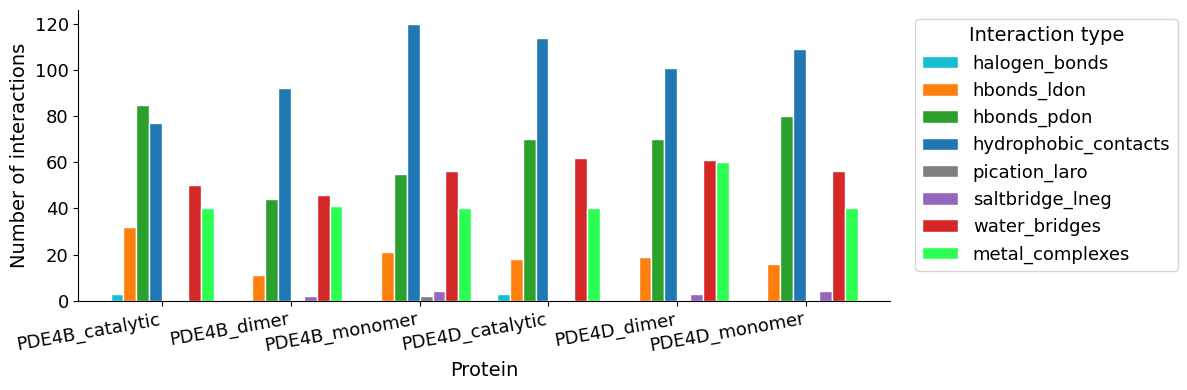

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

colors = {
    "hydrophobic_contacts": "#1f77b4",
    "hbonds_ldon": "#ff7f0e",
    "hbonds_pdon": "#2ca02c",
    "water_bridges": "#d62728",
    "saltbridge_lneg": "#9467bd",
    "saltbridge_pneg": "#8c564b",
    "pistacking": "#e377c2",
    "pication_laro": "#7f7f7f",
    "pication_paro": "#bcbd22",
    "halogen_bonds": "#17becf",
    "metal_complexes": "#2bff52",}

counts = (
    df[df["interaction_type"] != "metal_complexes"]
    .groupby(["protein", "interaction_type"])
    .size()
    .unstack(fill_value=0))

# Count unique ligand-metal complexes
metal_counts = (
    df[df["interaction_type"] == "metal_complexes"]
    [["protein", "ligand", "binding_site"]]
    .drop_duplicates()
    .groupby("protein")
    .size()
)

counts["metal_complexes"] = metal_counts
counts = counts.fillna(0)

ax = counts.plot(
    kind="bar",
    figsize=(12, 4),
    width=0.8,
    color=[colors.get(i, "#333333") for i in counts.columns],
    edgecolor="white",
    linewidth=1
)

ax.set_xlabel("Protein", fontsize=14)
ax.set_ylabel("Number of interactions", fontsize=14)

ax.tick_params(axis="both", labelsize=13)

ax.legend(
    title="Interaction type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=13,
    title_fontsize=14
)

plt.xticks(rotation=10, ha="right", fontsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [6]:
counts

interaction_type,halogen_bonds,hbonds_ldon,hbonds_pdon,hydrophobic_contacts,pication_laro,saltbridge_lneg,water_bridges,metal_complexes
protein,,,,,,,,
PDE4B_catalytic,3,32,85,77,0,0,50,40
PDE4B_dimer,0,11,44,92,0,2,46,41
PDE4B_monomer,0,21,55,120,2,4,56,40
PDE4D_catalytic,3,18,70,114,0,0,62,40
PDE4D_dimer,0,19,70,101,0,3,61,60
PDE4D_monomer,0,16,80,109,0,4,56,40


In [44]:
pd.set_option("display.max_columns", None)

df[
    (df["protein"] == "PDE4D_dimer") &
    (df["interaction_type"] == "metal_complexes") &
    (df["binding_site"].str.startswith("ZN:", na=False))

][[
    #"ligand",
    "binding_site",
    #"residue_number",
    #"residue_name",
    #"residue_chain",
    #"residue_id"
]].value_counts()

binding_site
ZN:A:1223       200
ZN:B:1223       200
Name: count, dtype: int64

In [45]:
pd.set_option("display.max_columns", None)

df[
    (df["protein"] == "PDE4B_dimer") &
    (df["interaction_type"] == "metal_complexes") &
    (df["binding_site"].str.startswith("ZN:", na=False))

][[
    #"ligand",
    "binding_site",
    #"residue_number",
    #"residue_name",
    #"residue_chain",
    #"residue_id"
]].value_counts()

binding_site
ZN:A:801        160
ZN:B:801        160
Name: count, dtype: int64

In [41]:
df[
    (df["protein"].isin(["PDE4B_dimer", "PDE4D_dimer"])) &
    (df["interaction_type"] == "metal_complexes")
][["protein", "ligand", "binding_site"]].value_counts(
    ["protein", "binding_site"]
)

protein      binding_site
PDE4D_dimer  ZN:A:1223       200
             MG:B:1224       200
             ZN:B:1223       200
PDE4B_dimer  ZN:A:801        160
             ZN:B:801        160
             MG:A:804          2
Name: count, dtype: int64

In [47]:
pd.set_option("display.max_columns", None)

df[
    (df["protein"] == "PDE4B_dimer") &
    (df["residue_chain"] == "B") 
    #(df["binding_site"].str.startswith("ZN:", na=False))

][[
    "ligand",
    "binding_site",
    "residue_number",
    "residue_name",
    "residue_chain",
    "residue_id"
]].value_counts()

ligand    binding_site  residue_number  residue_name  residue_chain  residue_id
10176710  ZN:B:801      446             HIS           B              HIS446:B      8
10394     ZN:B:801      446             HIS           B              HIS446:B      8
104775    ZN:B:801      446             HIS           B              HIS446:B      8
10559720  ZN:B:801      446             HIS           B              HIS446:B      8
107       ZN:B:801      446             HIS           B              HIS446:B      8
175       ZN:B:801      446             HIS           B              HIS446:B      8
348154    ZN:B:801      446             HIS           B              HIS446:B      8
439435    ZN:B:801      446             HIS           B              HIS446:B      8
49831816  ZN:B:801      446             HIS           B              HIS446:B      8
6262      ZN:B:801      446             HIS           B              HIS446:B      8
689043    ZN:B:801      446             HIS           B              H

In [50]:
df[
    (df["protein"] == "PDE4B_dimer") &
    (df["binding_site"] == "ZN:B:801") &
    (df["ligand"] == "m1")
]

,protein,ligand,binding_site,interaction_type,residue_number,residue_name,residue_chain,residue_id
849,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B
850,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B
851,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B
852,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B
853,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B
854,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B
855,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B
856,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B


In [49]:
pd.set_option("display.max_rows", None)

df[
    (df["protein"] == "PDE4D_dimer") &
    (df["residue_chain"] == "B") 
    #(df["binding_site"].str.startswith("ZN:", na=False))

][[
    "ligand",
    "binding_site",
    "residue_number",
    "residue_name",
    "residue_chain",
    "residue_id"
]].value_counts()

ligand    binding_site  residue_number  residue_name  residue_chain  residue_id
10176710  ZN:B:1223     502             HIS           B              HIS502:B      8
10559720  ZN:B:1223     502             HIS           B              HIS502:B      8
104775    ZN:B:1223     502             HIS           B              HIS502:B      8
10394     ZN:B:1223     502             HIS           B              HIS502:B      8
175       ZN:B:1223     502             HIS           B              HIS502:B      8
348154    ZN:B:1223     502             HIS           B              HIS502:B      8
107       ZN:B:1223     502             HIS           B              HIS502:B      8
m5        ZN:B:1223     502             HIS           B              HIS502:B      8
rolR      ZN:B:1223     502             HIS           B              HIS502:B      8
rolS      ZN:B:1223     502             HIS           B              HIS502:B      8
rf        ZN:B:1223     502             HIS           B              H

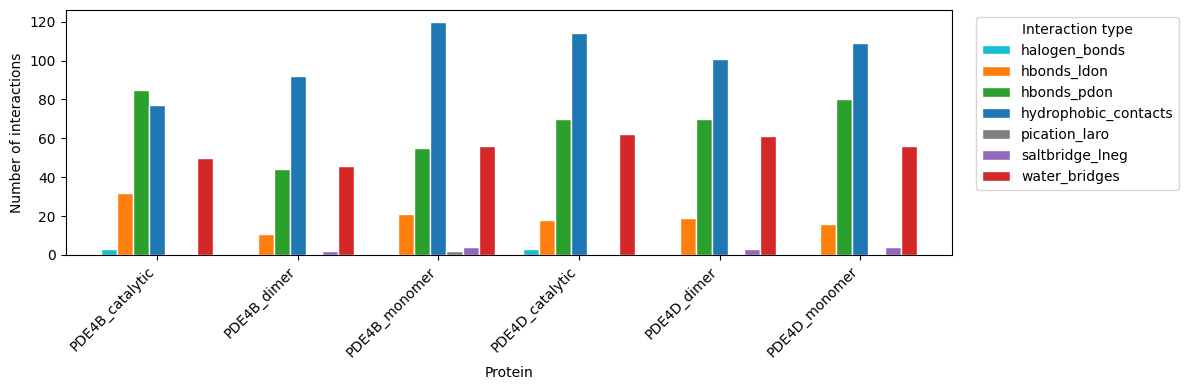

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

counts = (
    df_lig.groupby(["protein", "interaction_type"])
      .size()
      .unstack(fill_value=0)
)

ax = counts.plot(
    kind="bar",
    figsize=(12, 4),
    width=0.8,
    color=[colors.get(i, "#333333") for i in counts.columns],
    edgecolor="white",
    linewidth=1
)

ax.set_xlabel("Protein")
ax.set_ylabel("Number of interactions")
ax.legend(title="Interaction type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
counts

interaction_type,halogen_bonds,hbonds_ldon,hbonds_pdon,hydrophobic_contacts,pication_laro,saltbridge_lneg,water_bridges
protein,,,,,,,
PDE4B_catalytic,3,32,85,77,0,0,50
PDE4B_dimer,0,11,44,92,0,2,46
PDE4B_monomer,0,21,55,120,2,4,56
PDE4D_catalytic,3,18,70,114,0,0,62
PDE4D_dimer,0,19,70,101,0,3,61
PDE4D_monomer,0,16,80,109,0,4,56


In [26]:
counts.to_csv("interaction_counts.tsv", sep="\t")

In [27]:
for protein, group in df.groupby("protein"):
    print(protein, group["ligand"].nunique(), group["ligand"].unique())

PDE4B_catalytic 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4B_dimer 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4B_monomer 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4D_catalytic 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4D_dimer 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4D_monomer 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 

In [28]:
interaction_counts = (
    df.groupby(["protein", "ligand"])
      .size()
      .reset_index(name="n_interactions")
)

print(interaction_counts.to_string(index=False))

        protein   ligand  n_interactions
PDE4B_catalytic 10176710              42
PDE4B_catalytic    10394              36
PDE4B_catalytic   104775              23
PDE4B_catalytic 10559720              37
PDE4B_catalytic      107              33
PDE4B_catalytic      175              22
PDE4B_catalytic   348154              34
PDE4B_catalytic   439435              37
PDE4B_catalytic 49831816              40
PDE4B_catalytic     6262              26
PDE4B_catalytic   689043              35
PDE4B_catalytic  9877619              30
PDE4B_catalytic       m1              41
PDE4B_catalytic       m2              38
PDE4B_catalytic       m3              33
PDE4B_catalytic       m4              38
PDE4B_catalytic       m5              41
PDE4B_catalytic       rf              33
PDE4B_catalytic     rolR              39
PDE4B_catalytic     rolS              34
    PDE4B_dimer 10176710              48
    PDE4B_dimer    10394              48
    PDE4B_dimer   104775              48
    PDE4B_dimer 

In [29]:
for protein, group in df.groupby("protein"):
    print("\n", protein)
    print(group["ligand"].unique())


 PDE4B_catalytic
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4B_dimer
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4B_monomer
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4D_catalytic
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4D_dimer
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4D_monomer
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' '

In [30]:
from collections import Counter

pdb_file = "../pdbs/PDE4B_dimer_rolS.pdb"

atoms = []

with open(pdb_file) as f:
    for line in f:
        if line.startswith(("ATOM", "HETATM")):
            atom = line[12:16].strip()
            resname = line[17:20].strip()
            chain = line[21].strip()
            resid = line[22:26].strip()
            atoms.append((atom, resname, chain, resid))

print("Total atoms:", len(atoms))

Total atoms: 94461


In [31]:
from collections import Counter

counts = Counter(atoms)

duplicates = {k: v for k, v in counts.items() if v > 1}

print("Unique atom records:", len(counts))
print("Duplicated atom records:", len(duplicates))

for atom, n in list(duplicates.items())[:20]:
    print(n, atom)

Unique atom records: 33435
Duplicated atom records: 30198
3 ('N', 'VAL', 'A', '166')
3 ('CA', 'VAL', 'A', '166')
3 ('C', 'VAL', 'A', '166')
3 ('O', 'VAL', 'A', '166')
3 ('CB', 'VAL', 'A', '166')
3 ('CG1', 'VAL', 'A', '166')
3 ('CG2', 'VAL', 'A', '166')
3 ('HA', 'VAL', 'A', '166')
3 ('HB', 'VAL', 'A', '166')
3 ('1HG1', 'VAL', 'A', '166')
3 ('2HG1', 'VAL', 'A', '166')
3 ('3HG1', 'VAL', 'A', '166')
3 ('1HG2', 'VAL', 'A', '166')
3 ('2HG2', 'VAL', 'A', '166')
3 ('3HG2', 'VAL', 'A', '166')
2 ('HN2', 'VAL', 'A', '166')
2 ('HN1', 'VAL', 'A', '166')
2 ('HN3', 'VAL', 'A', '166')
2 ('HN4', 'VAL', 'A', '166')
6 ('N', 'THR', 'A', '167')


In [32]:
dimer = df[df["protein"] == "PDE4B_dimer"]

print(
    dimer.groupby(["ligand", "interaction_type"])
         .size()
         .unstack(fill_value=0)
         .to_string()
)

interaction_type  hbonds_ldon  hbonds_pdon  hydrophobic_contacts  metal_complexes  saltbridge_lneg  water_bridges
ligand                                                                                                           
10176710                    0            0                     0               48                0              0
10394                       0            0                     0               48                0              0
104775                      0            0                     0               48                0              0
10559720                    0            0                     0               48                0              0
107                         0            0                     0               48                0              0
175                         0            0                     0               48                0              0
348154                      0            0                     0               48       

In [33]:
print(
    dimer.groupby(["ligand", "residue_id"])
         .size()
         .sort_values(ascending=False)
         .head(30)
)

ligand    residue_id
10394     HIS446:B      16
10176710  HIS446:B      16
439435    HIS446:B      16
49831816  HIS446:B      16
6262      HIS446:B      16
348154    HIS446:B      16
107       HIS446:B      16
175       HIS446:B      16
10559720  HIS446:B      16
104775    HIS446:B      16
m5        HIS446:B      16
rolS      HIS446:B      16
rolR      HIS446:B      16
rf        HIS446:B      16
m3        HIS446:B      16
m4        HIS446:B      16
m2        HIS446:B      16
m1        HIS446:B      16
689043    HIS446:B      16
9877619   HIS446:B      16
m4        HIS281:B      12
m3        HIS281:B      12
rolR      HIS281:B      12
m5        HIS281:B      12
10176710  HIS281:B      12
10394     HIS281:B      12
m1        HIS281:B      12
m2        HIS281:B      12
9877619   HIS281:B      12
689043    HIS281:B      12
dtype: int64


In [18]:
import pandas as pd

interactions = pd.read_csv("plip_interactions.csv")

pde4b_water_bridges = interactions.loc[
    interactions["protein"].str.startswith("PDE4B")
    & interactions["interaction_type"].eq("water_bridges")
].copy()

ligands_by_protein = (
    pde4b_water_bridges.groupby("protein")["ligand"]
    .unique()
    .apply(sorted)
    .rename("ligands")
    .to_frame()
)

ligands_by_protein["n_ligands"] = ligands_by_protein["ligands"].str.len()

print("Ligantes com water bridges por forma de PDE4B:")
display(ligands_by_protein)

print("Residuos envolvidos:")
display(
    pde4b_water_bridges[
        ["protein", "ligand", "resnr", "restype", "reschain"]
    ].drop_duplicates().sort_values(["protein", "ligand", "resnr"])
)

Ligantes com water bridges por forma de PDE4B:


,ligands,n_ligands
protein,,
PDE4B_catalytic,"[10176710, 10394, 10559720, 348154, 439435, 49...",15
PDE4B_dimer,"[10176710, 10394, 104775, 107, 175, 348154, 43...",19
PDE4B_monomer,"[10176710, 10394, 104775, 10559720, 107, 175, ...",18


Residuos envolvidos:


,protein,ligand,resnr,restype,reschain
146,PDE4B_catalytic,10176710,405,TYR,A
147,PDE4B_catalytic,10176710,446,HIS,A
144,PDE4B_catalytic,10176710,450,HIS,A
148,PDE4B_catalytic,10176710,564,ASP,A
284,PDE4B_catalytic,10394,410,HIS,A
...,...,...,...,...,...
1653,PDE4B_monomer,m5,455,ASN,A
1650,PDE4B_monomer,m5,564,ASP,A
1651,PDE4B_monomer,m5,565,LEU,A
1706,PDE4B_monomer,rolR,567,ASN,A


In [14]:
teste = pde4b_water_bridges[
        ["protein", "ligand", "resnr", "restype", "reschain"]
    ].drop_duplicates().sort_values(["protein", "ligand", "resnr"])

In [17]:
teste[teste["restype"] == "HIS"]

,protein,ligand,resnr,restype,reschain
147,PDE4B_catalytic,10176710,446,HIS,A
144,PDE4B_catalytic,10176710,450,HIS,A
284,PDE4B_catalytic,10394,410,HIS,A
200,PDE4B_catalytic,689043,410,HIS,A
366,PDE4B_catalytic,m1,450,HIS,A
338,PDE4B_catalytic,m2,410,HIS,A
420,PDE4B_catalytic,m4,410,HIS,A
418,PDE4B_catalytic,m4,450,HIS,A
474,PDE4B_catalytic,m5,410,HIS,A
475,PDE4B_catalytic,m5,446,HIS,A


In [21]:
import pandas as pd

interactions = pd.read_csv("plip_interactions.csv")

pde4b_hydrophobic_contacts = interactions.loc[
    interactions["protein"].str.startswith("PDE4B")
    & interactions["interaction_type"].eq("hydrophobic_contacts")
].copy()

ligands_by_protein = (
    pde4b_hydrophobic_contacts.groupby("protein")["ligand"]
    .unique()
    .apply(sorted)
    .rename("ligands")
    .to_frame()
)

ligands_by_protein["n_ligands"] = ligands_by_protein["ligands"].str.len()

print("Ligantes com hydrophobic contacts por forma de PDE4B:")
display(ligands_by_protein)

print("Residuos envolvidos:")
display(
    pde4b_hydrophobic_contacts[
        ["protein", "ligand", "resnr", "restype", "reschain"]
    ].drop_duplicates().sort_values(["protein", "ligand", "resnr"])
)

Ligantes com hydrophobic contacts por forma de PDE4B:


,ligands,n_ligands
protein,,
PDE4B_catalytic,"[10176710, 10394, 104775, 10559720, 107, 34815...",19
PDE4B_dimer,"[10176710, 10394, 104775, 10559720, 107, 175, ...",20
PDE4B_monomer,"[10176710, 10394, 104775, 10559720, 107, 175, ...",20


Residuos envolvidos:


,protein,ligand,resnr,restype,reschain
139,PDE4B_catalytic,10176710,519,MET,A
135,PDE4B_catalytic,10176710,618,PHE,A
274,PDE4B_catalytic,10394,586,PHE,A
275,PDE4B_catalytic,10394,618,PHE,A
62,PDE4B_catalytic,104775,618,PHE,A
...,...,...,...,...,...
1701,PDE4B_monomer,rolR,618,PHE,A
1586,PDE4B_monomer,rolS,519,MET,A
1587,PDE4B_monomer,rolS,582,ILE,A
1588,PDE4B_monomer,rolS,586,PHE,A


In [22]:
hy = pde4b_hydrophobic_contacts[
        ["protein", "ligand", "resnr", "restype", "reschain"]
    ].drop_duplicates().sort_values(["protein", "ligand", "resnr"])

In [23]:
hy["restype"].value_counts()

restype
PHE    86
ILE    42
TYR    21
MET    19
HIS    10
SER     7
LEU     3
Name: count, dtype: int64

In [24]:
import pandas as pd

interactions = pd.read_csv("plip_interactions.csv")

hbonds_pdon = interactions.loc[
    interactions["protein"].str.startswith("PDE4B")
    & interactions["interaction_type"].eq("hbonds_pdon")
].copy()

ligands_by_protein = (
    hbonds_pdon.groupby("protein")["ligand"]
    .unique()
    .apply(sorted)
    .rename("ligands")
    .to_frame()
)

ligands_by_protein["n_ligands"] = ligands_by_protein["ligands"].str.len()

print("Ligantes com water bridges por forma de PDE4B:")
display(ligands_by_protein)

print("Residuos envolvidos:")
display(
    hbonds_pdon[
        ["protein", "ligand", "resnr", "restype", "reschain"]
    ].drop_duplicates().sort_values(["protein", "ligand", "resnr"])
)

Ligantes com water bridges por forma de PDE4B:


,ligands,n_ligands
protein,,
PDE4B_catalytic,"[10176710, 10394, 104775, 10559720, 107, 175, ...",20
PDE4B_dimer,"[10176710, 10394, 348154, 439435, 49831816, 62...",12
PDE4B_monomer,"[10394, 104775, 10559720, 107, 175, 348154, 43...",18


Residuos envolvidos:


,protein,ligand,resnr,restype,reschain
142,PDE4B_catalytic,10176710,406,HIS,A
279,PDE4B_catalytic,10394,567,ASN,A
280,PDE4B_catalytic,10394,615,GLN,A
65,PDE4B_catalytic,104775,405,TYR,A
64,PDE4B_catalytic,104775,567,ASN,A
...,...,...,...,...,...
1648,PDE4B_monomer,m5,406,HIS,A
1679,PDE4B_monomer,rf,406,HIS,A
1681,PDE4B_monomer,rf,615,GLN,A
1704,PDE4B_monomer,rolR,615,GLN,A


In [25]:
hbonds_pdon["restype"].value_counts()

restype
GLN    52
HIS    42
ASN    39
TYR    20
GLU    10
THR     9
SER     6
MET     4
ASP     1
TRP     1
Name: count, dtype: int64

In [26]:
# Em hbonds_pdon, a proteína doa e o ligante aceita
hbond_pdon_atoms = (
    hbonds_pdon[
        [
            "protein",
            "ligand",
            "resnr",
            "restype",
            "reschain",
            "donoridx",
            "donortype",
            "acceptoridx",
            "acceptortype",
            "dist_h-a",
            "don_angle",
        ]
    ]
    .drop_duplicates()
    .sort_values(["protein", "ligand", "resnr", "acceptoridx"])
)

print("Atomos do ligante que participaram de hbonds_pdon:")
display(hbond_pdon_atoms)

print("Resumo dos atomos do ligante por ligante:")
display(
    hbond_pdon_atoms[
        ["protein", "ligand", "acceptoridx", "acceptortype"]
    ].drop_duplicates().sort_values(["protein", "ligand", "acceptoridx"])
)

Atomos do ligante que participaram de hbonds_pdon:


,protein,ligand,resnr,restype,reschain,donoridx,donortype,acceptoridx,acceptortype,dist_h-a,don_angle
142,PDE4B_catalytic,10176710,406,HIS,A,NaN,NaN,NaN,NaN,NaN,NaN
279,PDE4B_catalytic,10394,567,ASN,A,NaN,NaN,NaN,NaN,NaN,NaN
280,PDE4B_catalytic,10394,615,GLN,A,NaN,NaN,NaN,NaN,NaN,NaN
65,PDE4B_catalytic,104775,405,TYR,A,NaN,NaN,NaN,NaN,NaN,NaN
64,PDE4B_catalytic,104775,567,ASN,A,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1648,PDE4B_monomer,m5,406,HIS,A,NaN,NaN,NaN,NaN,NaN,NaN
1679,PDE4B_monomer,rf,406,HIS,A,NaN,NaN,NaN,NaN,NaN,NaN
1681,PDE4B_monomer,rf,615,GLN,A,NaN,NaN,NaN,NaN,NaN,NaN
1704,PDE4B_monomer,rolR,615,GLN,A,NaN,NaN,NaN,NaN,NaN,NaN


Resumo dos atomos do ligante por ligante:


,protein,ligand,acceptoridx,acceptortype
142,PDE4B_catalytic,10176710,NaN,NaN
279,PDE4B_catalytic,10394,NaN,NaN
65,PDE4B_catalytic,104775,NaN,NaN
39,PDE4B_catalytic,10559720,NaN,NaN
305,PDE4B_catalytic,107,NaN,NaN
19,PDE4B_catalytic,175,NaN,NaN
252,PDE4B_catalytic,348154,NaN,NaN
225,PDE4B_catalytic,439435,NaN,NaN
113,PDE4B_catalytic,49831816,NaN,NaN
167,PDE4B_catalytic,6262,NaN,NaN


### specific residues

In [2]:
# 406
residue_406 = df[df["resnr"].eq(406)].copy()

interaction_type_counts_406 = (
    residue_406["interaction_type"]
    .value_counts()
    .rename_axis("interaction_type")
    .reset_index(name="count")
)

print(f"Total interactions involving residue 406: {len(residue_406)}")
display(interaction_type_counts_406)

# Inspect the records behind the counts, if needed.
display(
    residue_406[
        ["protein", "ligand", "binding_site", "interaction_type", "resnr", "restype", "reschain"]
    ]
    .sort_values(["count" if "count" in residue_406.columns else "interaction_type", "protein", "ligand"])
)

Total interactions involving residue 406: 70


,interaction_type,count
0,hbonds_pdon,39
1,water_bridges,10
2,hydrophobic_contacts,9
3,hbonds_ldon,6
4,saltbridge_lneg,4
5,pication_laro,2


,protein,ligand,binding_site,interaction_type,resnr,restype,reschain
360,PDE4B_catalytic,m1,UNL:Z:1,hbonds_ldon,406,HIS,A
409,PDE4B_catalytic,m4,UNL:Z:1,hbonds_ldon,406,HIS,A
571,PDE4B_dimer,10176710,UNL:Z:1,hbonds_ldon,406,HIS,A
719,PDE4B_dimer,6262,UNL:Z:1,hbonds_ldon,406,HIS,A
1119,PDE4B_monomer,689043,UNL:A:1,hbonds_ldon,406,HIS,A
...,...,...,...,...,...,...,...
1205,PDE4B_dimer,m3,UNL:Z:1,water_bridges,406,HIS,A
1491,PDE4B_dimer,m5,UNL:Z:1,water_bridges,406,HIS,A
1492,PDE4B_dimer,m5,UNL:Z:1,water_bridges,406,HIS,A
1460,PDE4B_dimer,rf,UNL:A:1,water_bridges,406,HIS,A
